In [135]:
import pandas as pd
import seaborn as sns

In [92]:
df_train = pd.read_csv("dataset/twitter_training.csv")
df_test = pd.read_csv("dataset/twitter_validation.csv")

In [93]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype
---  ------                                                 --------------  -----
 0   2401                                                   74681 non-null  int64
 1   Borderlands                                            74681 non-null  str  
 2   Positive                                               74681 non-null  str  
 3   im getting on borderlands and i will murder you all ,  73995 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [94]:
df_test.head()

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


## EDA

In [95]:
# changing the columns name
df_train.rename(columns={"2401":"tweet_id","Borderlands":"entity","Positive":"sentiment","im getting on borderlands and i will murder you all ,":"tweets"},inplace=True)
df_test.rename(columns={"3364":"tweet_id","Facebook":"entity","Irrelevant":"sentiment","I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣":"tweets"},inplace=True)

In [96]:
df_train.head()

,tweet_id,entity,sentiment,tweets
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [97]:
df_test.head()

,tweet_id,entity,sentiment,tweets
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [98]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   74681 non-null  int64
 1   entity     74681 non-null  str  
 2   sentiment  74681 non-null  str  
 3   tweets     73995 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [99]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   999 non-null    int64
 1   entity     999 non-null    str  
 2   sentiment  999 non-null    str  
 3   tweets     999 non-null    str  
dtypes: int64(1), str(3)
memory usage: 181.8 KB


In [100]:
## mising values
df_test.isnull().sum()

tweet_id     0
entity       0
sentiment    0
tweets       0
dtype: int64

In [101]:
df_train.isnull().sum()

tweet_id       0
entity         0
sentiment      0
tweets       686
dtype: int64

In [102]:
#dropping null rows
df_train.dropna(inplace=True)

In [103]:
df_train.isnull().sum()

tweet_id     0
entity       0
sentiment    0
tweets       0
dtype: int64

In [104]:
# duplicates value
df_train.duplicated().sum()

np.int64(2340)

In [105]:
df_test.duplicated().sum()

np.int64(0)

In [106]:
# dropping duplicated rows
df_train = df_train.drop_duplicates(keep='first')

In [107]:
df_train.duplicated().sum()

np.int64(0)

In [108]:
## Encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_train['sentiment'] = encoder.fit_transform(df_train['sentiment'])
df_test['sentiment'] = encoder.fit_transform(df_test['sentiment'])


In [109]:
df_train['sentiment'].unique()

array([3, 2, 1, 0])

In [110]:
df_test['sentiment'].unique()

array([2, 1, 3, 0])

In [111]:
df_train['text'] = df_train['entity'] + " " + df_train['tweets']
df_test['text'] = df_test['entity'] + " " + df_test['tweets']

In [112]:
df_train = df_train.drop(["tweet_id","entity","tweets"],axis=1)
df_test = df_test.drop(["tweet_id","entity","tweets"],axis=1)

In [117]:
df_train.head()

,sentiment,text
0,3,Borderlands I am coming to the borders and I w...
1,3,Borderlands im getting on borderlands and i wi...
2,3,Borderlands im coming on borderlands and i wil...
3,3,Borderlands im getting on borderlands 2 and i ...
4,3,Borderlands im getting into borderlands and i ...


## Preprocessing

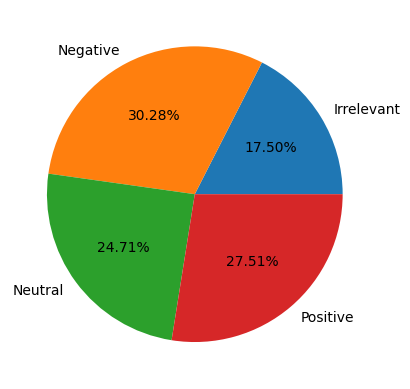

In [121]:
import matplotlib.pyplot as plt
counts = df_train['sentiment'].value_counts().sort_index()

plt.pie(
    counts,
    labels=['Irrelevant','Negative','Neutral','Positive'],
    autopct="%.2f%%"
)

plt.show()

In [115]:
## Data is already balanced so we doesnt have to change anything

In [116]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vansh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vansh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vansh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [122]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:] 
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y) 

In [124]:
transform_text("I absolutely love this Apple product!")

'absolut love appl product'

In [125]:
df_train['transformed_text'] = df_train['text'].apply(transform_text)
df_test['transformed_text'] = df_test['text'].apply(transform_text)

In [126]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

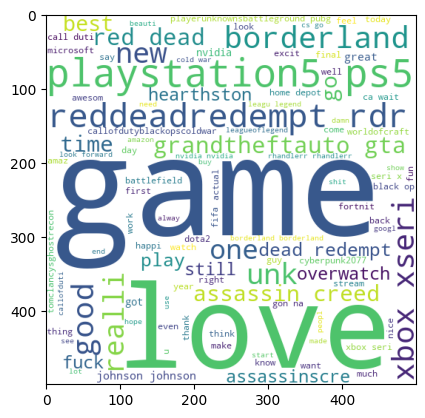

In [128]:
## for positive
positive_wc = wc.generate(df_train[df_train['sentiment']==3]['transformed_text'].str.cat(sep=" "))
plt.imshow(positive_wc)

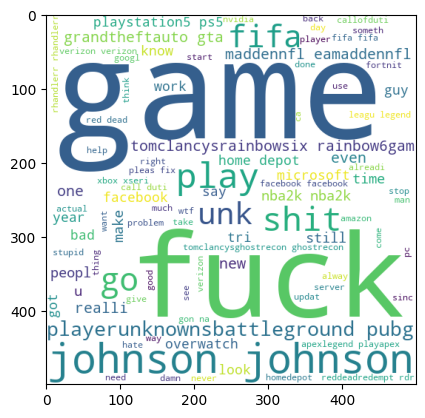

In [140]:
## for negative
negative_wc = wc.generate(df_train[df_train['sentiment']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(negative_wc)

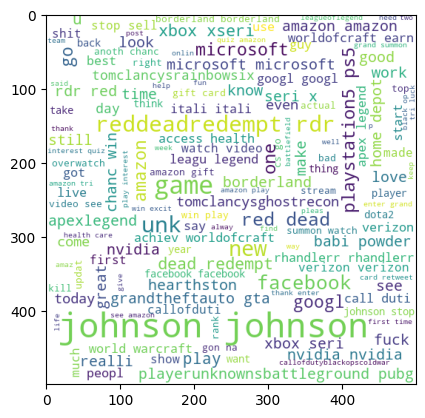

In [141]:
## for neutral
neutral_wc = wc.generate(df_train[df_train['sentiment']==2]['transformed_text'].str.cat(sep=" "))
plt.imshow(neutral_wc)

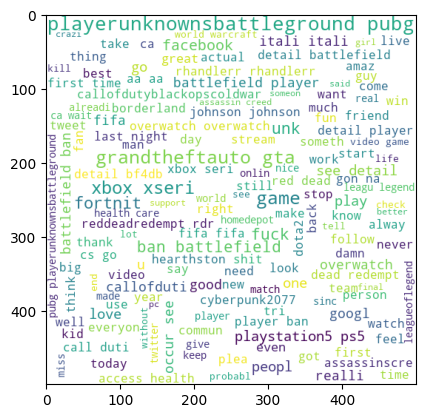

In [131]:
## for irrelevant
irrelevant_wc = wc.generate(df_train[df_train['sentiment']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(irrelevant_wc)

<function matplotlib.pyplot.show(close=None, block=None)>

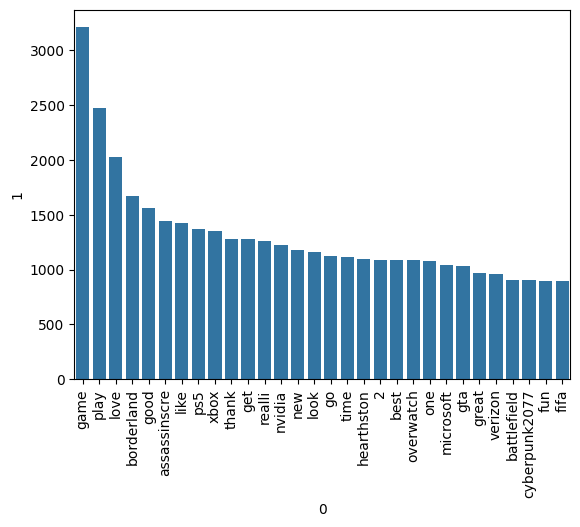

In [144]:
positive_corpus = []
for msg in df_train[df_train['sentiment'] == 3]['transformed_text'].tolist():
    for word in msg.split():
        positive_corpus.append(word)

from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(positive_corpus).most_common(30))[0], y = pd.DataFrame(Counter(positive_corpus).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

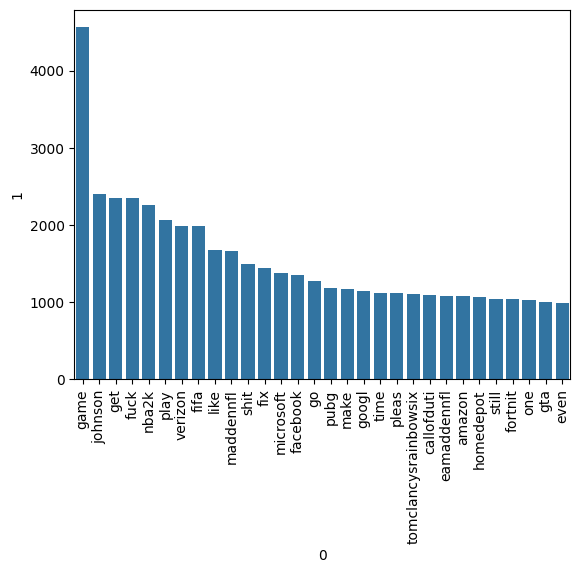

In [145]:
negative_corpus = []
for msg in df_train[df_train['sentiment'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        negative_corpus.append(word)

from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(negative_corpus).most_common(30))[0], y = pd.DataFrame(Counter(negative_corpus).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

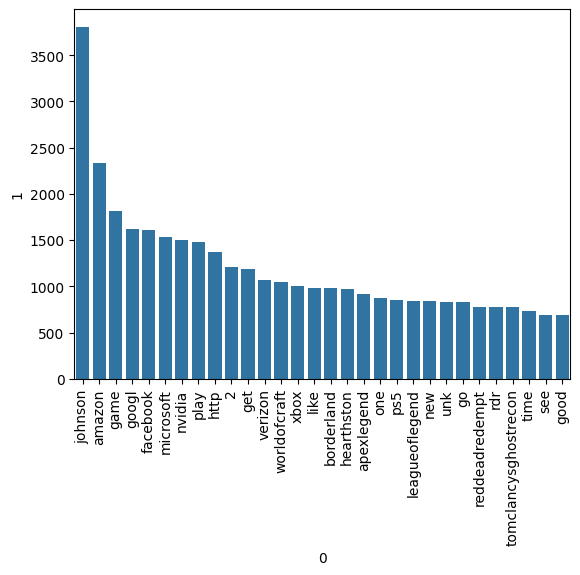

In [146]:
neutral_corpus = []
for msg in df_train[df_train['sentiment'] == 2]['transformed_text'].tolist():
    for word in msg.split():
        neutral_corpus.append(word)

from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(neutral_corpus).most_common(30))[0], y = pd.DataFrame(Counter(neutral_corpus).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

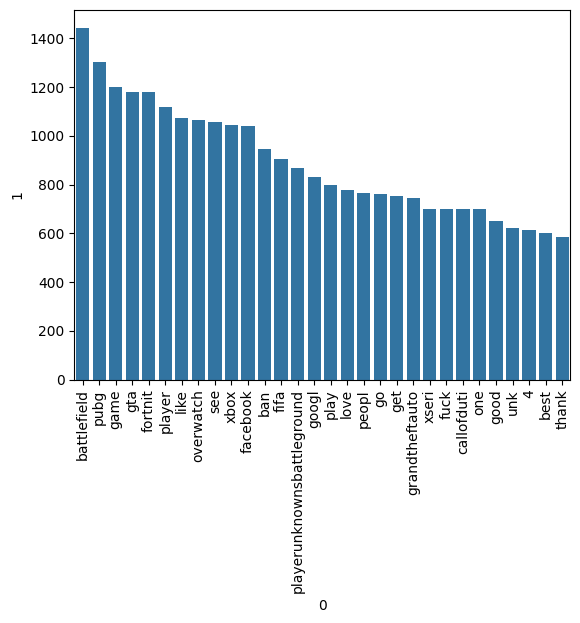

In [147]:
irrelevant_corpus = []
for msg in df_train[df_train['sentiment'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        irrelevant_corpus.append(word)

from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(irrelevant_corpus).most_common(30))[0], y = pd.DataFrame(Counter(irrelevant_corpus).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show

## Model Building

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(max_features=5000)

In [ ]:
X_train = tf.fit_transform(df_train['transformed_text'])
X_test = tf.transform(df_test['transformed_text'])

In [179]:
Y_train = df_train['sentiment']
Y_test = df_test['sentiment']

In [162]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

mnb = MultinomialNB()
lr = LogisticRegression(max_iter=1000,random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svc = LinearSVC()

In [180]:
mnb.fit(X_train,Y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(Y_test,y_pred1))
print(confusion_matrix(Y_test,y_pred1))
print(precision_score(Y_test,y_pred1,average='weighted'))

0.6816816816816816
[[117  16  13  25]
 [ 22 186  27  31]
 [ 28  43 168  46]
 [ 20  23  24 210]]
0.6851079711195966


In [181]:
lr.fit(X_train,Y_train)
y_pred2 = lr.predict(X_test)
print(accuracy_score(Y_test,y_pred2))
print(confusion_matrix(Y_test,y_pred2))
print(precision_score(Y_test,y_pred2,average='weighted'))

0.8508508508508509
[[137  10  12  12]
 [  7 234   9  16]
 [  7  29 238  11]
 [ 12  12  12 241]]
0.8516886751504052


In [182]:
rf.fit(X_train,Y_train)
y_pred3 = rf.predict(X_test)
print(accuracy_score(Y_test,y_pred3))
print(confusion_matrix(Y_test,y_pred3))
print(precision_score(Y_test,y_pred3,average='weighted'))

0.968968968968969
[[165   2   3   1]
 [  1 259   3   3]
 [  0   3 276   6]
 [  4   2   3 268]]
0.968975534993309


In [183]:
svc.fit(X_train,Y_train)
y_pred4 = svc.predict(X_test)
print(accuracy_score(Y_test,y_pred4))
print(confusion_matrix(Y_test,y_pred4))
print(precision_score(Y_test,y_pred4,average='weighted'))

0.8538538538538538
[[133  13  11  14]
 [  5 237  10  14]
 [  7  29 237  12]
 [  9  13   9 246]]
0.8556710188232428


In [187]:
## now we dump the data using pickle
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(svc,open('model.pkl','wb'))

In [188]:
## we taking random forest beacause of highest accuracy comapre to others
## due to increase in size of model.pkl very high i am using svc 